# NP-01 — The ndarray: shapes, axes, and dtypes

**Worked solutions · English · NumPy 2.3.5 · CPU only**

[Lesson](lesson.ipynb) · [Review note](../../../reference/numpy/ndarray-shapes-axes-dtypes.md) · [Setup and validation](README.md) · [Curriculum](../../../docs/CURRICULUM.md)

A model can train without an exception and still average over the wrong dimension. This chapter develops the habit of treating an array's **shape, axis meanings, and dtype as part of its contract**, before writing the computation.

**Prerequisites:** Python variables, functions, lists, tuples, indexing, loops, and elementary averages. FND-01/FND-02 are the planned prerequisite units; they are not written yet. You do not need calculus or previous NumPy mastery.

**How to work:** predict first, run the worked examples, complete E01–E09, and explain failed predictions. Every exercise has three optional hints and executable checks. In this learner notebook, `NotImplementedError` is intentional. The adjacent solution is designed to run from a fresh kernel without edits.

**Learning outcomes:**
1. Explain `shape`, `ndim`, `size`, `dtype`, `itemsize`, and `nbytes` (E01).
2. Distinguish scalar, vector, row, column, singleton, and empty shapes (E02).
3. Derive output shapes and choose reduction axes from semantic names (E03–E04).
4. Preserve element meaning when permuting dimensions (E05).
5. Choose integer storage and convert image values safely (E06–E07).
6. Explain why later casting cannot recover lost information (E08).
7. Combine these ideas in a small image preprocessing pipeline (E09).

**Scope:** a complete first lesson on the array model, not the full NumPy API. Constructors, indexing, promotion, memory layout, and broadcasting receive deeper treatment in NP-02 through NP-08. No datasets, network calls, GPUs, or training runs are required. Suggested study time: two focused sessions of 60–90 minutes; this is a planning estimate, not a measured learner outcome. Execution timings are in the validation report.


## 0. Reproducible setup

Use the locked environment described in the local README. The notebook checks the NumPy version so that a different kernel does not silently change the experiment. Matplotlib is used only for diagnostics; plotting proficiency is not a prerequisite. All data below are deterministic and created here, so no random seed is needed.

The helper checks exact expected exceptions in examples. It does not suppress arbitrary failures. `assert_array_equal` checks exact discrete results; `assert_allclose` checks approximate floating-point results with explicit tolerances.


In [1]:
import math
import platform
import sys
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png")
from numpy.testing import assert_array_equal, assert_allclose

assert np.__version__ == "2.3.5", "Select the pinned NumPy foundations kernel."
assert matplotlib.__version__ == "3.10.8"
print(f"Python {platform.python_version()} | NumPy {np.__version__} | Matplotlib {matplotlib.__version__}")
np.set_printoptions(precision=5, suppress=True)


def expect_error(error_type, operation):
    """Verify that an operation raises the expected exception.

    Args:
        error_type: Exception class expected from the operation.
        operation: Zero-argument callable to execute.

    Raises:
        AssertionError: If the operation returns without raising.
    """
    try:
        operation()
    except error_type:
        return
    raise AssertionError(f"Expected {error_type.__name__}")


Python 3.12.14 | NumPy 2.3.5 | Matplotlib 3.10.8


## 1. An array is data plus a way to interpret it

Start with six temperature readings: two days, three sensors per day. A nested Python list represents containers inside containers. A numeric ndarray instead gives the collection a single element representation and a multidimensional indexing scheme. Array objects may share storage; the array object is not synonymous with an independently owned allocation.

The three questions to ask are: **which element does an index identify, what does that index mean, and how are its bytes interpreted?** NumPy knows the indexing scheme and dtype, but not that axis 0 means “day.” That meaning is your responsibility.

Source: [ndarray — definition and internal memory layout](https://numpy.org/doc/2.3/reference/arrays.ndarray.html).


In [2]:
readings = np.array([[11, 13, 17], [19, 23, 29]], dtype=np.int16)
print(readings)
print(type(readings), readings.dtype)
print("Day 1, sensor 2:", readings[1, 2])
print("List * 2:", [11, 13, 17] * 2)
print("Array * 2:", readings[0] * 2)
assert readings[1, 2] == 29


[[11 13 17]
 [19 23 29]]
<class 'numpy.ndarray'> int16
Day 1, sensor 2: 29
List * 2: [11, 13, 17, 11, 13, 17]
Array * 2: [22 26 34]


### Six attributes, six different questions

| Expression | Question | For `readings` | Reference |
|---|---|---|---|
| `a.shape` | How long is each axis, in order? | `(2, 3)` | [shape](https://numpy.org/doc/2.3/reference/generated/numpy.ndarray.shape.html) |
| `a.ndim` | How many axes? | `2` | [ndim](https://numpy.org/doc/2.3/reference/generated/numpy.ndarray.ndim.html) |
| `a.size` | How many logical elements? | `6` | [size](https://numpy.org/doc/2.3/reference/generated/numpy.ndarray.size.html) |
| `a.dtype` | What is one element's representation? | `int16` | [dtype attribute](https://numpy.org/doc/2.3/reference/generated/numpy.ndarray.dtype.html) |
| `a.itemsize` | How many bytes per element slot? | `2` | [itemsize](https://numpy.org/doc/2.3/reference/generated/numpy.ndarray.itemsize.html) |
| `a.nbytes` | How many bytes do the logical element slots account for? | `12` | [nbytes](https://numpy.org/doc/2.3/reference/generated/numpy.ndarray.nbytes.html) |

If the shape is $(d_0,\ldots,d_{n-1})$, choose an index on each axis. There are $d_0$ choices for the first, $d_1$ for the second, and so on. Therefore

$$\mathrm{ndim}=n,\qquad \mathrm{size}=\prod_{k=0}^{n-1}d_k,\qquad \mathrm{nbytes}=\mathrm{size}\times\mathrm{itemsize}.$$

These equations count logical slots. They do **not** measure Python object overhead, the entire backing allocation of a view, or referenced Python objects in an object array. A shared view can have a nonzero `nbytes` without owning additional element storage.

**Predict:** if a dataset has shape `(8, 12, 5)` and dtype `float32`, what are its number of axes, element count, and logical byte count?


In [3]:
demo = np.zeros((8, 12, 5), dtype=np.float32)
print({name: getattr(demo, name) for name in
       ("shape", "ndim", "size", "dtype", "itemsize", "nbytes")})
assert demo.ndim == 3 and demo.size == 480 and demo.nbytes == 1920


{'shape': (8, 12, 5), 'ndim': 3, 'size': 480, 'dtype': dtype('float32'), 'itemsize': 4, 'nbytes': 1920}


### NP-01-E01 — Write an array inspection report

Implement `describe_array(a)` for any ndarray. Return exactly the six keys in the example above. Return `dtype` as `a.dtype.name`, a string; leave shape as a tuple. Do not change the input. Your function must work for a 0-D array and an empty array as well as an ordinary matrix.


**Solution reasoning.** Each attribute answers a separate question. `len(a)` is not a replacement for `a.size`: it measures only the first axis and is undefined for a 0-D array. The scalar and empty cases prevent a matrix-only implementation.


In [4]:
def describe_array(a):
    """Return shape, ndim, size, dtype name, itemsize, and nbytes for an array."""
    return {"shape": a.shape, "ndim": a.ndim, "size": a.size,
            "dtype": a.dtype.name, "itemsize": a.itemsize, "nbytes": a.nbytes}


In [5]:
assert describe_array(readings) == {
    "shape": (2, 3), "ndim": 2, "size": 6,
    "dtype": "int16", "itemsize": 2, "nbytes": 12}
assert describe_array(np.array(7, dtype=np.int32))["size"] == 1
empty_report = describe_array(np.empty((2, 0, 3), dtype=np.float64))
assert empty_report["shape"] == (2, 0, 3)
assert empty_report["ndim"] == 3 and empty_report["nbytes"] == 0
assert_array_equal(readings, [[11, 13, 17], [19, 23, 29]])
print("E01 passed: ordinary, scalar, and empty arrays.")


E01 passed: ordinary, scalar, and empty arrays.


## 2. Shape is a tuple, not a picture

`(4,)` is a one-element tuple containing the axis length 4. `(4)` is just the integer 4 in parentheses. A `(4,)` vector has one axis; neither “row” nor “column” orientation is encoded. A row has shape `(1, 4)`; a column has shape `(4, 1)`.

A 0-D ndarray has shape `()`. It has one value but no axes: the empty product gives `size = 1`. An empty array such as `(2, 0, 3)` has three axes but zero elements. A length-one axis still exists; its index can only be 0.

A Python scalar, a NumPy scalar such as `np.int16(7)`, and a 0-D ndarray are different objects. The last is still an array. For the ordinary numeric dtypes used here, `.item()` extracts a Python scalar. Unusual types such as extended-precision floats have additional details in the API reference.

Sources: [shape](https://numpy.org/doc/2.3/reference/generated/numpy.ndarray.shape.html), [NumPy scalar types](https://numpy.org/doc/2.3/reference/arrays.scalars.html), [item](https://numpy.org/doc/2.3/reference/generated/numpy.ndarray.item.html).


In [6]:
examples = {
    "0-D": np.array(7, dtype=np.int16),
    "vector": np.array([7], dtype=np.int16),
    "matrix": np.array([[7]], dtype=np.int16),
    "empty": np.empty((2, 0, 3), dtype=np.int16),
}
for name, a in examples.items():
    print(name, "shape=", a.shape, "ndim=", a.ndim, "size=", a.size)
scalar = examples["0-D"]
print(type(scalar), type(scalar[()]), type(scalar.item()))
expect_error(TypeError, lambda: len(scalar))
assert len(np.zeros((2, 3))) == 2
assert np.zeros((2, 3)).size == 6


0-D shape= () ndim= 0 size= 1
vector shape= (1,) ndim= 1 size= 1
matrix shape= (1, 1) ndim= 2 size= 1
empty shape= (2, 0, 3) ndim= 3 size= 0
<class 'numpy.ndarray'> <class 'numpy.int16'> <class 'int'>


### Give a vector an explicit orientation

`reshape` changes shape while preserving the element count and its requested traversal order. Here we use its default C order. It may share storage or require a copy; do not infer ownership from the new shape. Only one dimension can be inferred using `-1`. We use explicit dimensions in E02 so that the empty-vector case is unambiguous.

Transposing a one-dimensional vector does not turn it into a column: there is only one axis to permute. Source: [reshape](https://numpy.org/doc/2.3/reference/generated/numpy.reshape.html) and [transpose](https://numpy.org/doc/2.3/reference/generated/numpy.transpose.html).


In [7]:
v = np.array([2, 5, 9], dtype=np.int32)
print("Vector:", v.shape, "transpose:", v.T.shape)
print("Row:", v.reshape((1, 3)))
print("Column:", v.reshape((3, 1)))
assert v.T.shape == (3,)
expect_error(ValueError, lambda: v.reshape((2, 2)))


Vector: (3,) transpose: (3,)
Row: [[2 5 9]]
Column: [[2]
 [5]
 [9]]


### NP-01-E02 — Make row and column contracts explicit

Given a 1-D ndarray `v`, return `(row, column)` with shapes `(1, n)` and `(n, 1)`, preserving dtype and element order. Reject non-1-D inputs with `ValueError`. Support an empty vector. Do not promise independent storage; the caller must not assume that mutating an output leaves the input unchanged.


**Solution reasoning.** The new singleton axis expresses orientation. Checking `ndim` avoids silently flattening a matrix whose structure might matter. Explicit dimensions handle length zero without attempting to infer an ambiguous dimension.


In [8]:
def row_and_column(v):
    """Return explicit row and column forms of a one-dimensional array."""
    if v.ndim != 1:
        raise ValueError("Expected a one-dimensional array")
    return v.reshape((1, v.size)), v.reshape((v.size, 1))


In [9]:
for values in (np.array([2, 5, 9], dtype=np.int32), np.array([], dtype=np.float32)):
    row, column = row_and_column(values)
    assert row.shape == (1, values.size) and column.shape == (values.size, 1)
    assert row.dtype == values.dtype and column.dtype == values.dtype
    assert_array_equal(row[0], values)
    assert_array_equal(column[:, 0], values)
expect_error(ValueError, lambda: row_and_column(np.zeros((2, 2))))
expect_error(ValueError, lambda: row_and_column(np.array(3)))
print("E02 passed: orientation, empty vector, and invalid rank.")


E02 passed: orientation, empty vector, and invalid rank.


**Explain without running code:** why can `(2, 0, 3)` have more axes but fewer elements than `()`?

**Discussion:** Axis count is the length of the shape tuple; element count is its product. Three axis lengths including zero yield zero elements, while the empty product for a scalar is one.


## 3. An axis is a coordinate; reduction removes its choices

Consider $X$ with shape $(B,T,C)$: batch, time, sensor channel. The value $X_{b,t,c}$ is one sensor reading at one time in one batch item. To average over time, hold $b$ and $c$ fixed and sum over $t$:

$$M_{b,c}=\frac{1}{T}\sum_{t=0}^{T-1}X_{b,t,c}.$$

The indices still needed are $(b,c)$, so the result has shape $(B,C)$. Averaging over batch and time leaves only channel:

$$\mu_c=\frac{1}{BT}\sum_{b=0}^{B-1}\sum_{t=0}^{T-1}X_{b,t,c}.$$

Thus `axis` names the axes you **aggregate over**, not the axes you keep. With `keepdims=True`, reduced axes remain with length 1. This preserves their positions for later broadcasting. For `(B,T,C)`:

| Reduction axes | Output shape | With `keepdims=True` |
|---|---|---|
| `0` | `(T, C)` | `(1, T, C)` |
| `1` | `(B, C)` | `(B, 1, C)` |
| `-1` (same as `2`) | `(B, T)` | `(B, T, 1)` |
| `(0, 1)` | `(C,)` | `(1, 1, C)` |
| `None` | `()` | `(1, 1, 1)` |

Source: [mean — axis and keepdims](https://numpy.org/doc/2.3/reference/generated/numpy.mean.html). The equations above explain the choices in our sensor example; axis names are an application convention.


In [10]:
sensor_data = np.array([
    [[1, 10, 100], [3, 14, 104]],
    [[5, 18, 108], [7, 22, 112]],
], dtype=np.float64)
print("Input:", sensor_data.shape)
print("Mean over time:", sensor_data.mean(axis=1))
print("Mean for each sensor:", sensor_data.mean(axis=(0, 1)))
print("Retained axes:", sensor_data.mean(axis=(0, 1), keepdims=True).shape)
assert_array_equal(sensor_data.mean(axis=(0, 1)), [4, 16, 106])


Input: (2, 2, 3)
Mean over time: [[  2.  12. 102.]
 [  6.  20. 110.]]
Mean for each sensor: [  4.  16. 106.]
Retained axes: (1, 1, 3)


### NP-01-E03 — Predict a reduction shape without allocating data

Implement `reduced_shape(shape, axes, keepdims=False)` using Python tuples and integers only: no NumPy arrays and no call to a reduction. For this exercise, `shape` is a valid tuple of non-negative Python integers and `axes` is a tuple of distinct valid non-negative axis indices. Input validation and negative-axis normalization are deliberately outside this function's contract. An empty axis tuple means no reduction. Return the output shape. This exercise makes the shape rule explicit before using it in code.


**Solution reasoning.** An unreduced axis keeps its length and position relative to other survivors. A reduced axis either disappears or becomes length one. The huge dimension check makes accidental allocation impractical and reinforces that this is metadata reasoning.


In [11]:
def reduced_shape(shape, axes, keepdims=False):
    """Predict a reduction shape for valid non-negative axis indices."""
    if keepdims:
        return tuple(1 if i in axes else length for i, length in enumerate(shape))
    return tuple(length for i, length in enumerate(shape) if i not in axes)


In [12]:
assert reduced_shape((2, 4, 3), (1,)) == (2, 3)
assert reduced_shape((2, 4, 3), (0, 2), True) == (1, 4, 1)
assert reduced_shape((2, 4, 3), (0, 1, 2)) == ()
assert reduced_shape((2, 0, 3), (1,)) == (2, 3)
assert reduced_shape((2, 4, 3), ()) == (2, 4, 3)
assert reduced_shape((), ()) == ()
assert reduced_shape((10**20, 3), (1,)) == (10**20,)
for axes in ((), (0,), (1,), (2,), (0, 2), (0, 1, 2)):
    for keep in (False, True):
        actual = np.zeros((2, 4, 3)).sum(axis=axes, keepdims=keep).shape
        assert reduced_shape((2, 4, 3), axes, keep) == actual
print("E03 passed: shape algebra, including scalar and empty dimensions.")


E03 passed: shape algebra, including scalar and empty dimensions.


### NP-01-E04 — Compute one mean per sensor

`x` is a finite real numeric ndarray of shape `(batch, time, channels)` with positive axis lengths. Return a `float64` array of shape `(channels,)` averaging over batch and time. Raise `ValueError` for a wrong rank or any zero-length axis. Do not modify `x`. Use one vectorized mean call. Explain why `axis=-1` would answer a different question.


**Solution reasoning.** Only the channel index survives. `axis=-1` would average different sensors together at each batch/time location. An explicit float64 accumulator makes the contract independent of input precision; it cannot restore information already absent from the stored input. Empty means are undefined for this application, so reject them explicitly.


In [13]:
def sensor_mean(x):
    """Compute one float64 mean per channel of a nonempty (B, T, C) array."""
    if x.ndim != 3 or any(length == 0 for length in x.shape):
        raise ValueError("Expected nonempty batch, time, and channel axes")
    return x.mean(axis=(0, 1), dtype=np.float64)


In [14]:
x = np.arange(24, dtype=np.int16).reshape((2, 4, 3))
before = x.copy()
expected = [sum(float(x[b, t, c]) for b in range(2) for t in range(4)) / 8
            for c in range(3)]
result = sensor_mean(x)
assert result.shape == (3,) and result.dtype == np.dtype("float64")
assert_allclose(result, expected, rtol=0, atol=1e-12)
assert_array_equal(sensor_mean(np.ones((1, 1, 1), dtype=np.float32)), [1.0])
assert_array_equal(x, before)
expect_error(ValueError, lambda: sensor_mean(np.zeros((2, 3))))
expect_error(ValueError, lambda: sensor_mean(np.zeros((2, 0, 3))))
expect_error(ValueError, lambda: sensor_mean(np.zeros((2, 3, 0))))
print("E04 passed against an independent Python-loop calculation.")


E04 passed against an independent Python-loop calculation.


### Visual checkpoint: an axis mistake can produce believable numbers

The same matrix supports two different questions. The plot below labels the surviving coordinate in each reduction. It is scaffolding, not a plotting exercise. Predict each bar height before running it.


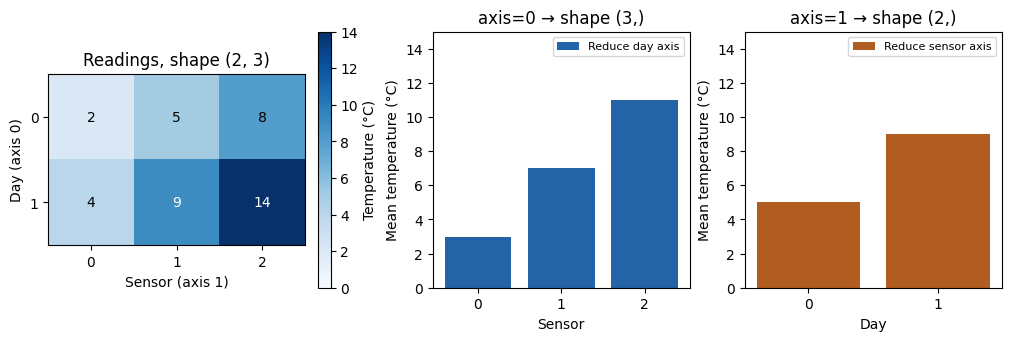

In [15]:
grid = np.array([[2, 5, 8], [4, 9, 14]], dtype=np.float64)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.3), layout="constrained")
image = axes[0].imshow(grid, cmap="Blues", vmin=0, vmax=14)
for r in range(2):
    for c in range(3):
        axes[0].text(c, r, str(int(grid[r, c])), ha="center", va="center",
                     color="white" if grid[r, c] > 8 else "black")
axes[0].set(xticks=[0, 1, 2], yticks=[0, 1], xlabel="Sensor (axis 1)",
            ylabel="Day (axis 0)", title="Readings, shape (2, 3)")
fig.colorbar(image, ax=axes[0], label="Temperature (°C)")
axes[1].bar(range(3), grid.mean(axis=0), color="#2463a6", label="Reduce day axis")
axes[1].set(xticks=[0, 1, 2], xlabel="Sensor", ylabel="Mean temperature (°C)",
            title="axis=0 → shape (3,)", ylim=(0, 15))
axes[2].bar(range(2), grid.mean(axis=1), color="#b15c20", label="Reduce sensor axis")
axes[2].set(xticks=[0, 1], xlabel="Day", ylabel="Mean temperature (°C)",
            title="axis=1 → shape (2,)", ylim=(0, 15))
axes[1].legend(fontsize=8); axes[2].legend(fontsize=8)
display(fig)
plt.close(fig)


## 4. The right shape can still contain the wrong data

A permutation reassigns coordinate positions. A reshape regroups elements according to a traversal order. Both can produce the same output shape while defining different correspondences between input and output elements.

For image data in `(batch, height, width, channels)` order, the desired conversion is

`out[b, c, h, w] == images[b, h, w, c]`.

This equation is the contract. Merely checking that the result has shape `(B, C, H, W)` cannot verify it. Sources: [transpose](https://numpy.org/doc/2.3/reference/generated/numpy.transpose.html), [reshape](https://numpy.org/doc/2.3/reference/generated/numpy.reshape.html).


In [16]:
images = np.empty((2, 3, 4, 3), dtype=np.int16)
for b, h, w, c in np.ndindex(images.shape):
    images[b, h, w, c] = 1000*b + 100*h + 10*w + c
correct_layout = images.transpose((0, 3, 1, 2))
wrong_layout = images.reshape((2, 3, 3, 4))
print("Same output shape:", correct_layout.shape == wrong_layout.shape)
print("Same values at corresponding coordinates:", np.array_equal(correct_layout, wrong_layout))
print("Required value:", images[1, 2, 1, 0], "correct:", correct_layout[1, 0, 2, 1],
      "wrong:", wrong_layout[1, 0, 2, 1])
assert not np.array_equal(correct_layout, wrong_layout)


Same output shape: True
Same values at corresponding coordinates: False
Required value: 1210 correct: 1210 wrong: 1030


### NP-01-E05 — Convert an image layout without scrambling channels

Implement NHWC → NCHW for a 4-D ndarray using a permutation, not reshaping or copying individual pixels. Raise `ValueError` for any other rank. Preserve dtype. A view is acceptable; no independent-storage promise is made.


**Solution reasoning.** The output axes select input axes 0, 3, 1, 2. Coordinate-coded input makes a mistaken reshape detectable even when dimensions happen to have equal lengths. Its inverse is 0, 2, 3, 1. Empty batches still have a well-defined axis permutation.


In [17]:
def nhwc_to_nchw(x):
    """Reorder a four-dimensional array from NHWC to NCHW."""
    if x.ndim != 4:
        raise ValueError("Expected NHWC data with four axes")
    return x.transpose((0, 3, 1, 2))


In [18]:
result = nhwc_to_nchw(images)
assert result.shape == (2, 3, 3, 4) and result.dtype == images.dtype
for b, h, w, c in np.ndindex(images.shape):
    assert result[b, c, h, w] == images[b, h, w, c]
assert_array_equal(result.transpose((0, 2, 3, 1)), images)
assert nhwc_to_nchw(np.empty((0, 2, 4, 3))).shape == (0, 3, 2, 4)
expect_error(ValueError, lambda: nhwc_to_nchw(np.zeros((2, 3, 4))))
print("E05 passed: every coordinate and the inverse permutation.")


E05 passed: every coordinate and the inverse permutation.


## 5. A dtype is a representation contract

`type(a)` describes the Python array object; `a.dtype` describes its elements. For ordinary numeric arrays, every element uses the same scalar type. NumPy chooses a common dtype when constructing an array from mixed inputs; it does not preserve an independent numeric type for every element as a Python list can.

| Family | Examples | One design question |
|---|---|---|
| Boolean | `bool` | Is this a mask or a measurement? |
| Signed integer | `int8`, `int16`, `int32`, `int64` | Must negative values be represented? |
| Unsigned integer | `uint8`, `uint16` | Are values genuinely non-negative? |
| Floating point | `float32`, `float64` | What resolution is needed at the relevant magnitude? |
| Complex | `complex64`, `complex128` | What precision is needed for each real component? |
| Other | strings, dates, structured records, `object` | Is numeric homogeneous storage actually appropriate? |

One dtype need not mean one simple number: a structured dtype can describe fields. An object array stores references to Python objects. It is not a shortcut to efficient heterogeneous numerical computation. Fixed-width string, datetime, and structured APIs are later chapters.

Use explicit-width names when a storage contract matters. A dtype also describes details such as byte order; those belong to serialization and interoperability, not merely the number of printed decimals.

Sources: [dtype objects — what a dtype describes](https://numpy.org/doc/2.3/reference/arrays.dtypes.html), [data types](https://numpy.org/doc/2.3/user/basics.types.html), [dtype constructor](https://numpy.org/doc/2.3/reference/generated/numpy.dtype.html).


In [19]:
for values in ([1, 2, 3], [1, 2.5, 3], [True, False], [1, "two"]):
    a = np.array(values)
    print(repr(values), "→", a.dtype, a)
explicit = np.array([1, 2, 3], dtype=np.float32)
assert explicit.itemsize == 4
ragged = [[1, 2], [3]]
expect_error(ValueError, lambda: np.array(ragged))
objects = np.array(ragged, dtype=object)
print("Object array:", objects.shape, objects.dtype)
print("Object slot bytes:", objects.nbytes, "(not the total size of its lists)")


[1, 2, 3] → int64 [1 2 3]
[1, 2.5, 3] → float64 [1.  2.5 3. ]
[True, False] → bool [ True False]
[1, 'two'] → <U21 ['1' 'two']
Object array: (2,) object
Object slot bytes: 16 (not the total size of its lists)


### Finite integers are not Python's arbitrary-precision integers

A signed $b$-bit integer represents values from $-2^{b-1}$ through $2^{b-1}-1$. An unsigned one represents $0$ through $2^b-1$. Thus a byte has 256 possible bit patterns; interpreting it as signed changes which numbers they denote, not its size.

`np.iinfo(dtype)` reports integer limits. Choose a dtype for the **intermediate computation**, not only the input values. In particular, widening after overflow preserves an already corrupted result. NumPy integer-array arithmetic need not emit a warning when it overflows. Python's integer arithmetic behaves differently. Out-of-range construction and overflowing arithmetic are also different operations; do not assume one tells you how the other behaves.

Sources: [iinfo](https://numpy.org/doc/2.3/reference/generated/numpy.iinfo.html), [data types — overflow errors](https://numpy.org/doc/2.3/user/basics.types.html), [promotion — numerical precision](https://numpy.org/doc/2.3/reference/arrays.promotion.html).


In [20]:
pixels = np.array([0, 200, 255], dtype=np.uint8)
wrapped = pixels + np.array([1, 100, 1], dtype=np.uint8)
widened_first = pixels.astype(np.uint16) + np.array([1, 100, 1], dtype=np.uint16)
print("Stored in uint8:", wrapped)
print("Widened before addition:", widened_first)
print("Widened after addition:", wrapped.astype(np.uint16))
assert_array_equal(wrapped, [1, 44, 0])
assert_array_equal(widened_first, [1, 300, 256])
print("Python integers:", 200 + 100)


Stored in uint8: [ 1 44  0]
Widened before addition: [  1 300 256]
Widened after addition: [ 1 44  0]
Python integers: 300


### NP-01-E06 — Choose the smallest signed storage dtype

Inputs `low` and `high` are Python integers describing an inclusive range. Return an `np.dtype` object for the smallest of `int8`, `int16`, `int32`, `int64` that holds the entire range. Use `np.iinfo`, not manually copied bounds. Raise `ValueError` if `low > high`, and `OverflowError` if no candidate fits. This is a storage decision; it does not guarantee that later arithmetic stays within range.


**Solution reasoning.** Testing both endpoints is sufficient because the range is contiguous. Ascending candidate widths establish minimality. A common error is to choose uint8 for 0–255: this exercise explicitly asks for a signed type, so int16 is required.


In [21]:
def smallest_signed_dtype(low, high):
    """Choose the smallest signed integer dtype covering an inclusive range."""
    if low > high:
        raise ValueError("The lower bound exceeds the upper bound")
    for candidate in (np.int8, np.int16, np.int32, np.int64):
        limits = np.iinfo(candidate)
        if limits.min <= low and high <= limits.max:
            return np.dtype(candidate)
    raise OverflowError("No supported signed dtype can represent this range")


In [22]:
assert smallest_signed_dtype(-128, 127) == np.dtype("int8")
assert smallest_signed_dtype(-129, 127) == np.dtype("int16")
assert smallest_signed_dtype(0, 255) == np.dtype("int16")
assert smallest_signed_dtype(-32768, 32767) == np.dtype("int16")
assert smallest_signed_dtype(-32769, 32768) == np.dtype("int32")
assert smallest_signed_dtype(-(2**63), 2**63 - 1) == np.dtype("int64")
expect_error(ValueError, lambda: smallest_signed_dtype(2, 1))
expect_error(OverflowError, lambda: smallest_signed_dtype(0, 2**63))
expect_error(OverflowError, lambda: smallest_signed_dtype(-(2**63)-1, 0))
print("E06 passed: inclusive boundaries and unsupported ranges.")


E06 passed: inclusive boundaries and unsupported ranges.


### Conversion changes representation, not the original data's history

`a.astype(dtype)` returns a converted array and, by default, copies. It does not mutate the source. Some conversions discard information: converting finite in-range floating values to integers truncates toward zero. Do not use conversion as an implicit rounding policy. `copy=False` may avoid a copy when requirements are already satisfied; it does not promise a view in every case.

The default casting policy permits potentially lossy conversions. For production interfaces, specify and test the allowed range and dtype rather than trusting a plausible output.

Source: [astype — dtype, casting, and copy](https://numpy.org/doc/2.3/reference/generated/numpy.ndarray.astype.html).


In [23]:
measurements = np.array([-2.9, 1.2, 3.8], dtype=np.float64)
integers = measurements.astype(np.int32)
print("Truncation:", integers)
assert_array_equal(integers, [-2, 1, 3])
assert measurements.dtype == np.dtype("float64")
expect_error(TypeError, lambda: measurements.astype(np.int32, casting="safe"))


Truncation: [-2  1  3]


### NP-01-E07 — Normalize unsigned image values safely

Implement `normalize_uint8(x)` for a uint8 ndarray of any shape, including scalar and empty shapes. Return an independent `float32` array with values `x / 255` and the same shape; preserve the input. Reject any non-uint8 dtype with `TypeError`. The dtype and divisor are part of the contract, not implementation details. Do not use floor division or an in-place division of the uint8 input.


**Solution reasoning.** The cast allocates independent floating storage before division. The in-place operation is safe on this new floating array and preserves its shape even for a 0-D input. Integer floor division would destroy fractional intensities; casting only after it would not repair them.


In [24]:
def normalize_uint8(x):
    """Convert uint8 values to an independent float32 array in [0, 1]."""
    if x.dtype != np.dtype("uint8"):
        raise TypeError("Expected uint8 input")
    result = x.astype(np.float32)
    result /= np.float32(255)
    return result


In [25]:
x = np.array([[0, 1], [128, 255]], dtype=np.uint8)
before = x.copy()
result = normalize_uint8(x)
assert result.shape == x.shape and result.dtype == np.dtype("float32")
assert_allclose(result, [[0, 1/255], [128/255, 1]], rtol=1e-7, atol=0)
assert not np.shares_memory(x, result)
result[0, 0] = 0.5
assert_array_equal(x, before)
assert normalize_uint8(np.array(255, dtype=np.uint8)).shape == ()
assert normalize_uint8(np.empty((0, 3), dtype=np.uint8)).shape == (0, 3)
expect_error(TypeError, lambda: normalize_uint8(np.array([0, 255], dtype=np.int16)))
print("E07 passed: values, dtype, shape, ownership, and invalid input type.")


E07 passed: values, dtype, shape, ownership, and invalid input type.


## 6. Precision depends on magnitude: a controlled experiment

A finite floating-point format has a finite significand. Around 1, `np.finfo(np.float32).eps` is the gap to the next larger representable value; it is **not a universal absolute tolerance**. The distance between representable values grows as their exponent grows. A number can be well within the format's range and still lack the required resolution.

Source: [finfo — eps, nmant, and numerical limits](https://numpy.org/doc/2.3/reference/generated/numpy.finfo.html).

Our test signal contains two measurements: $2^k$ and $2^k+1$. Their true difference is exactly 1. We vary only $k$, keeping the signal difference and operations fixed. For $k$ from 0 through 40, both source integers are exactly representable in float64. This makes float64 a valid baseline for **this experiment**, not a universally exact number system.

Compare three paths:
1. Store and subtract in float64.
2. Store and subtract in float32.
3. Store in float32, cast to float64, then subtract.

Before running: will path 3 recover the information lost in path 2? At what exponent do you expect the first failure for the pair used here?


### NP-01-E08 — Measure storage loss separately from arithmetic precision

Implement `precision_gaps(exponents)`. The input is a 1-D ndarray of integer exponents in `[0, 40]`; validation is outside the exercise contract. Return three 1-D arrays `(gap64, gap32, gap32_then64)` in the order described above. Each contains the observed difference between `2**k + 1` and `2**k`. Construct the source in float64 before creating float32 versions. Do not round or repair results to match the baseline.


**Solution reasoning.** Float32 has 24 bits of significand precision including its leading bit. At 2**24, the next larger float32 number is two units away; 2**24 + 1 rounds to 2**24 under the usual ties-to-even rule. Once both stored values are identical, wider subtraction cannot distinguish them. The result is specific to this pair and range; not every large integer rounds downward, and float64 also has finite precision.


In [26]:
def precision_gaps(exponents):
    """Compare a unit gap before and after float32 storage."""
    base64 = np.float64(2) ** exponents
    next64 = base64 + np.float64(1)
    base32 = base64.astype(np.float32)
    next32 = next64.astype(np.float32)
    return (next64 - base64,
            next32 - base32,
            next32.astype(np.float64) - base32.astype(np.float64))


In [27]:
exponents = np.arange(0, 41, dtype=np.int64)
gap64, gap32, recovered = precision_gaps(exponents)
assert gap64.shape == gap32.shape == recovered.shape == (41,)
assert gap64.dtype == recovered.dtype == np.dtype("float64")
assert gap32.dtype == np.dtype("float32")
assert_array_equal(gap64, np.ones(41))
assert_array_equal(gap32[:24], np.ones(24))
assert_array_equal(gap32[24:], np.zeros(17))
assert_array_equal(recovered, gap32.astype(np.float64))
assert precision_gaps(np.array([], dtype=np.int64))[0].shape == (0,)
print("E08 passed: the first lost unit gap is at k=24 for this signal.")


E08 passed: the first lost unit gap is at k=24 for this signal.


float32 epsilon at 1: 1.1920929e-07


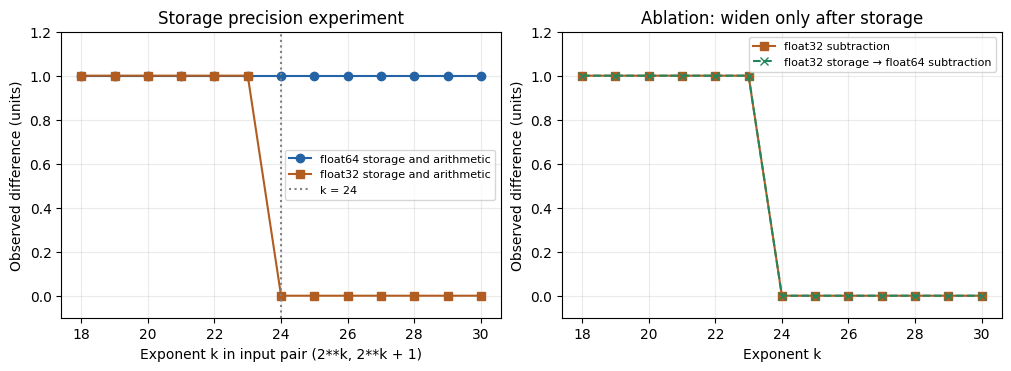

In [28]:
exponents = np.arange(18, 31, dtype=np.int64)
gap64, gap32, recovered = precision_gaps(exponents)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), layout="constrained")
axes[0].plot(exponents, gap64, "o-", label="float64 storage and arithmetic", color="#2463a6")
axes[0].plot(exponents, gap32, "s-", label="float32 storage and arithmetic", color="#b15c20")
axes[0].set(xlabel="Exponent k in input pair (2**k, 2**k + 1)",
            ylabel="Observed difference (units)", title="Storage precision experiment", ylim=(-0.1, 1.2))
axes[0].axvline(24, color="0.5", linestyle=":", label="k = 24")
axes[1].plot(exponents, gap32, "s-", label="float32 subtraction", color="#b15c20")
axes[1].plot(exponents, recovered, "x--", label="float32 storage → float64 subtraction", color="#24865d")
axes[1].set(xlabel="Exponent k", ylabel="Observed difference (units)",
            title="Ablation: widen only after storage", ylim=(-0.1, 1.2))
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
display(fig)
plt.close(fig)
print("float32 epsilon at 1:", np.finfo(np.float32).eps)


**Interpret the experiment:** what changed, what stayed fixed, and what can you conclude about the cause of the failure?

**Discussion:** Only the input magnitude changes along the horizontal axis. The true unit difference stays fixed. Changing only subtraction precision after float32 storage leaves the loss unchanged, isolating information loss in storage/conversion for this construction. It does not establish a general error bound for every float32 algorithm.


## 7. Memory: logical size is not ownership

A small slice can keep a large backing array alive. A transpose can change the indexing scheme without copying its elements. Use `np.shares_memory` when the question is whether two arrays overlap, rather than guessing from their shape. Strides and ownership will be developed fully in NP-05.

This example is deliberately tiny: it demonstrates the distinction without allocating a large dataset. Source: [copies and views](https://numpy.org/doc/2.3/user/basics.copies.html).


In [29]:
base = np.arange(12, dtype=np.int32)
view = base[::3]
independent = view.copy()
print("Logical bytes:", base.nbytes, view.nbytes, independent.nbytes)
print("Shared storage:", np.shares_memory(base, view), np.shares_memory(base, independent))
view[0] = 99
assert base[0] == 99 and independent[0] == 0
assert view.nbytes == view.size * view.itemsize == 16


Logical bytes: 48 16 16
Shared storage: True False


## 8. Transfer: a shape-aware image preprocessing contract

You receive uint8 NHWC images. Produce normalized, channel-centered NCHW data while retaining the per-channel means for inspection. Derive the shapes before implementing:

$$U_{b,h,w,c}=I_{b,h,w,c}/255,\qquad
\mu_c=\frac{1}{BHW}\sum_{b,h,w}U_{b,h,w,c},\qquad
Y_{b,c,h,w}=U_{b,h,w,c}-\mu_c.$$

To subtract within NHWC layout, represent means as `(1, 1, 1, C)`. The singleton axes can match the batch and spatial lengths during broadcasting. This is the only broadcast pattern required here; NP-06 develops the general rules. Source: [broadcasting — compatible axes](https://numpy.org/doc/2.3/user/basics.broadcasting.html).

In a real train/test pipeline, estimate dataset statistics on training data and reuse them. This exercise centers its supplied batch to study axes; it is not a recommendation to fit preprocessing independently on every test batch.


### NP-01-E09 — Build and audit the complete preprocessing pipeline

Implement `prepare_images(images)` for a nonempty 4-D uint8 NHWC ndarray with any positive channel count. Return `(centered_nchw, means_nhwc)`, both float32. Their shapes must be `(B, C, H, W)` and `(1, 1, 1, C)`. Preserve the input and reject wrong rank or zero-length axes with `ValueError`, then wrong dtype with `TypeError`. Reuse E05 and E07. Keep the mean axes explicitly so the subtraction is structurally clear. Explain why centered output is not constrained to `[0, 1]`.


**Solution reasoning.** Normalize first, reduce batch/height/width, subtract in NHWC, and then permute. Removing a mean shifts some values below zero, so only the pre-centering array is guaranteed to lie in [0, 1]. The tests check coordinate values and centered means: either alone would miss some bugs. The small numerical tolerance accounts for float32 rounding rather than accepting a structural error.


In [30]:
def prepare_images(images):
    """Normalize and channel-center a nonempty uint8 NHWC image batch."""
    if images.ndim != 4 or any(length == 0 for length in images.shape):
        raise ValueError("Expected nonempty NHWC data")
    normalized = normalize_uint8(images)
    means = normalized.mean(axis=(0, 1, 2), dtype=np.float32, keepdims=True)
    centered = normalized - means
    return nhwc_to_nchw(centered), means


In [31]:
raw = np.array([[[[0, 255], [64, 128]], [[128, 64], [255, 0]]]], dtype=np.uint8)
before = raw.copy()
centered, means = prepare_images(raw)
assert centered.shape == (1, 2, 2, 2) and means.shape == (1, 1, 1, 2)
assert centered.dtype == means.dtype == np.dtype("float32")
reference_means = [sum(float(raw[b, h, w, c]) / 255
                      for b in range(1) for h in range(2) for w in range(2)) / 4
                   for c in range(2)]
assert_allclose(means[0, 0, 0], reference_means, rtol=0, atol=1e-7)
for b, h, w, c in np.ndindex(raw.shape):
    assert_allclose(centered[b, c, h, w], float(raw[b, h, w, c])/255 - reference_means[c],
                    rtol=0, atol=1e-7)
assert_allclose(centered.mean(axis=(0, 2, 3)), 0, rtol=0, atol=1e-7)
assert_array_equal(raw, before)
assert not np.shares_memory(centered, raw)
assert np.any(centered < 0)
for invalid in (np.zeros((2, 2), dtype=np.uint8), np.empty((0, 2, 2, 3), dtype=np.uint8)):
    expect_error(ValueError, lambda invalid=invalid: prepare_images(invalid))
expect_error(TypeError, lambda: prepare_images(raw.astype(np.float32)))
for shape in ((2, 3, 4, 3), (1, 1, 1, 1)):
    constant = np.full(shape, 127, dtype=np.uint8)
    z, m = prepare_images(constant)
    assert_allclose(z, 0, rtol=0, atol=1e-6)
    assert_allclose(m, 127/255, rtol=0, atol=1e-6)
print("E09 passed: independent values, zero channel means, dtype, layout, and input preservation.")


E09 passed: independent values, zero channel means, dtype, layout, and input preservation.


## 9. Reconstruct the chapter from memory

Without looking above, explain: (1) why a vector transpose is not a column; (2) which axes a per-channel image mean removes; (3) why float64 cannot recover a previously rounded float32 value; (4) why `nbytes` is not process memory usage. Then change E09 to center each image separately: which axes and mean shape change?

**Discussion:** A vector has one axis, so permuting it changes no orientation. A dataset-wide channel mean removes batch and spatial axes. Equal stored float32 values remain equal after widening. Logical byte accounting excludes array-object overhead and does not track all backing storage or referenced objects. For per-image centering in NHWC, reduce `(1, 2)` and retain mean shape `(B, 1, 1, C)`; that is a different statistical operation.


## 10. API map and reading guide

The **core API** for this lesson is `ndarray` and its `shape`, `ndim`, `size`, `dtype`, `itemsize`, and `nbytes` attributes. Exercise E01 checks these directly. The constructors, conversion, reductions, and permutations below are supporting tools introduced here and revisited in later units.

| API / expression | Meaning in this lesson | Practice |
|---|---|---|
| `np.array(values, dtype=...)` | Construct a typed array from values | Worked examples; E01 inputs |
| `np.dtype(name)` | Describe an element representation | E06 |
| `a.reshape(shape)` | Regroup traversal into a compatible shape | E02 |
| `a.mean(axis=..., dtype=..., keepdims=...)` | Aggregate selected coordinates | E04, E09 |
| `a.transpose(axes)` | Permute coordinate positions | E05, E09 |
| `np.iinfo(dtype)` | Inspect representable integer bounds | E06 |
| `a.astype(dtype)` | Convert representation | E07, E08 |
| `np.finfo(dtype)` | Inspect floating-point limits and precision | E08 interpretation |
| `a.item()` | Extract a scalar for ordinary numeric dtypes | Worked scalar example |
| `a.copy()`, `np.shares_memory(a, b)` | Separate copying from overlap | Worked memory example; E07/E09 checks |

The inventory records lesson-level coverage, not mastery of all overloads or every member of `ndarray`. Utility calls such as `np.ndindex`, `np.zeros`, `np.arange`, and test assertions scaffold the examples; they are not declared exhaustively taught here.

**Essential reading (NumPy 2.3 documentation; accessed October 4, 2026):**
- [ndarray](https://numpy.org/doc/2.3/reference/arrays.ndarray.html): definition, array attributes, and the axis example. Reconstruct our attribute table without copying it.
- [mean](https://numpy.org/doc/2.3/reference/generated/numpy.mean.html): `axis`, `dtype`, `keepdims`, and Notes. Explain an accumulator dtype versus a final-result cast.
- [data types](https://numpy.org/doc/2.3/user/basics.types.html): array types, overflow errors, and NumPy scalars. Identify a dtype choice that changes correctness.

**Further study:**
- [dtype objects](https://numpy.org/doc/2.3/reference/arrays.dtypes.html): type interpretation and byte order; revisit in NP-03/NP-19.
- [copies and views](https://numpy.org/doc/2.3/user/basics.copies.html): reshape behavior and memory sharing; NP-05.
- [promotion](https://numpy.org/doc/2.3/reference/arrays.promotion.html): interactions with Python scalars; NP-03.
- [indexing](https://numpy.org/doc/2.3/user/basics.indexing.html): scalar selection versus axis-preserving slices; NP-04.

The examples, exercises, coordinate encodings, and precision ablation are original teaching constructions. Sources document the API semantics. The runtime is pinned to patch version 2.3.5; the official documentation URLs are versioned at the 2.3 release-series level.

**Next:** NP-02 — creation and conversion (planned). For a fast revisit, use the [review note](../../../reference/numpy/ndarray-shapes-axes-dtypes.md).
